In [7]:
import sys

sys.path.append("../src/")
sys.path.append("../src/AtomicTrit")

from AtomicTrit import elastic
from AtomicTrit import constants
from AtomicTrit import potentials
import numpy as np
import pylab as plt
import pandas as pd
import json
from scipy.interpolate import interp1d

from potentials import ExtendedMF, ModifiedMF, R2, HFD_B




In [8]:
#Here are the masses and atom names we will need

m4He_ov_mH=4.0026/1.008
m3He_ov_mH=3.0160/1.008
mT_ov_mH=constants.TritiumConstants.mu/constants.HydrogenConstants.mu
mD_ov_mH=2.0141/1.008

HAtoms=["H","D","T"]
HeAtoms=["3He","4He"]

HMasses=[1,2.0141/1.008,constants.TritiumConstants.mu/constants.HydrogenConstants.mu]
HeMasses=[3.0160/1.008,4.0026/1.008]

MuBySpecies={}
for Hi in range(0,len(HMasses)):
    for Hei in range(0,len(HeMasses)):
        muC=2.*HMasses[Hi]*HeMasses[Hei]/(HMasses[Hi]+HeMasses[Hei])
        name= HAtoms[Hi]+"-"+HeAtoms[Hei]
        MuBySpecies[name]=muC

kB=8.617e-5


(0.0, 10.0)

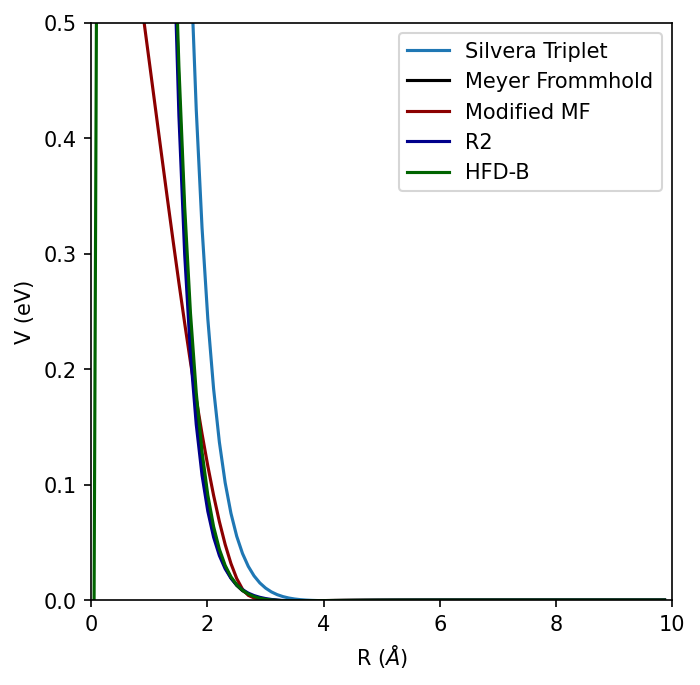

In [9]:
#Plot potentials. For comparison also can include the Silvert triplet

R=np.linspace(1e-5,0.005,100)
plt.figure(figsize=(5,5),dpi=150)
plt.plot(R*constants.hcInEVAngstrom, potentials.Silvera_Triplet(R),label='Silvera Triplet')
plt.plot(R*constants.hcInEVAngstrom, ExtendedMF(R),label='Meyer Frommhold',color='black')
plt.plot(R*constants.hcInEVAngstrom, ModifiedMF(R),label='Modified MF',color='DarkRed')
plt.plot(R*constants.hcInEVAngstrom, R2(R),label='R2',color='DarkBlue')
plt.plot(R*constants.hcInEVAngstrom, HFD_B(R),label='HFD-B',color='DarkGreen')
plt.xlabel(r"R ($\AA$)")
plt.ylabel("V (eV)")
plt.legend(loc='upper right')
plt.ylim(0,0.5)
plt.xlim(0,10)

(2.0, 6.0)

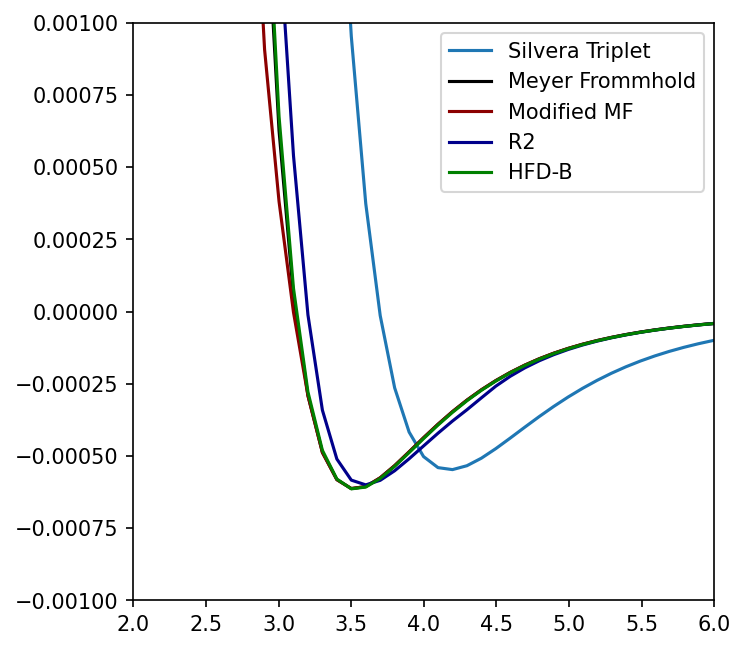

In [10]:
#Make inset plot

R=np.linspace(1e-5,0.005,100)
plt.figure(figsize=(5,5),dpi=150)
plt.plot(R*constants.hcInEVAngstrom, potentials.Silvera_Triplet(R),label='Silvera Triplet')
plt.plot(R*constants.hcInEVAngstrom, ExtendedMF(R),label='Meyer Frommhold',color='black')
plt.plot(R*constants.hcInEVAngstrom, ModifiedMF(R),label='Modified MF',color='DarkRed')
plt.plot(R*constants.hcInEVAngstrom, potentials.R2(R),label='R2',color='DarkBlue')
plt.plot(R*constants.hcInEVAngstrom, potentials.HFD_B(R),label='HFD-B',color='Green')

plt.legend(loc='upper right')
plt.ylim(-0.001,0.001)
plt.xlim(2,6)


In [11]:
#Calculate scattering length vs reduced mass

scatlengthsMF=[]
scatlengthsMod=[]
scatlengthsR2=[]
scatlengthsHFD_B= []
r0       = 1e-9
pin      = 1e-4
intlimit = 100 * constants.BohrInAng/constants.hcInEVAngstrom
rhos = np.linspace(r0, intlimit, 100)

muH=constants.HydrogenConstants.mu

mus=np.linspace(1,5,100)

for mu in mus:

    scatlengthsMF.append(elastic.GetScatteringLength(rhos, pin, 0, mu*muH, ExtendedMF, 'Radau')[-1]*constants.hcInEVAngstrom)
    scatlengthsMod.append(elastic.GetScatteringLength(rhos, pin, 0, mu*muH, ModifiedMF, 'Radau')[-1]*constants.hcInEVAngstrom)
    scatlengthsR2.append(elastic.GetScatteringLength(rhos, pin, 0, mu*muH, R2, 'Radau')[-1]*constants.hcInEVAngstrom)
    scatlengthsHFD_B.append(elastic.GetScatteringLength(rhos, pin, 0, mu*muH, HFD_B, 'Radau')[-1]*constants.hcInEVAngstrom)


H-3He 1.4990059642147118 3.845359444932634 -0.6829634297774461 10.57854377095751 1.485894164411083
H-4He 1.597652975691534 -19.06067392330155 -23.125228308403525 -10.309032554989846 -20.65374304987801
D-3He 2.396101500711747 -312.13923729552835 -308.74746163871026 -272.7037193788635 -304.56458761473823
D-4He 2.6584856870599056 -493.0716470181679 -481.17538571976775 -425.7492750890497 -475.493198274559
T-3He 2.993162160100278 -880.2324029431187 -842.6834719148594 -735.1678192816311 -833.5090009644287
T-4He 3.4140852245876068 -2195.8618466525863 -1993.2758354974333 -1614.2322338049073 -1964.8820092968863


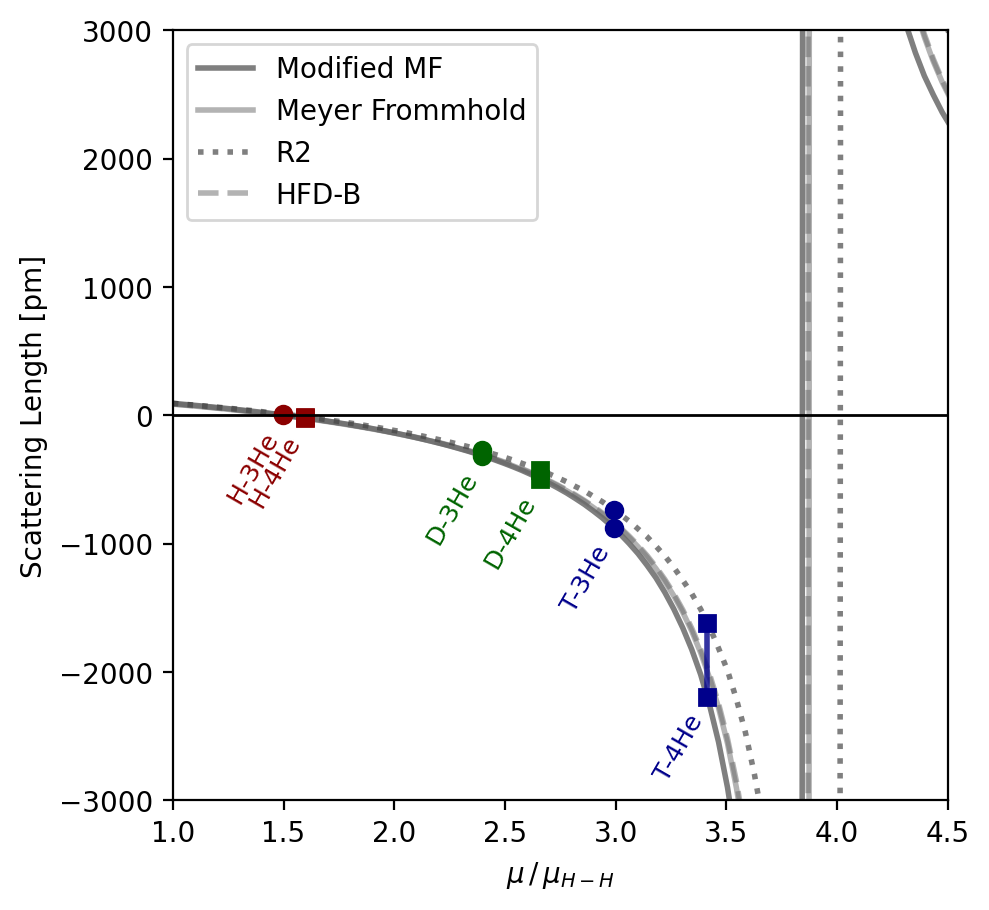

In [12]:
#Make zero energy limit scat length plot

plt.figure(figsize=(5,5),dpi=200)

plt.plot(mus,np.array(scatlengthsMod)*100,label='Modified MF',color='black',linewidth=2, alpha = 0.5)
plt.plot(mus,np.array(scatlengthsMF)*100,label='Meyer Frommhold',color='dimgrey',linewidth=2, alpha = 0.5)
plt.plot(mus,np.array(scatlengthsR2)*100,label='R2',color='black',linewidth=2, linestyle = ':', alpha = 0.5)
plt.plot(mus,np.array(scatlengthsHFD_B)*100,label='HFD-B',color='dimgrey',linewidth=2, linestyle = '--', alpha = 0.5)
Markers=['o','s']
# LineStyles=['-',':']
Colors=['DarkRed','DarkGreen','DarkBlue']
for Hi in range(0,len(HMasses)):
    for Hei in range(0,len(HeMasses)):
        RedMass=2.*HMasses[Hi]*HeMasses[Hei]/(HMasses[Hi]+HeMasses[Hei])
        a1 = elastic.GetScatteringLength(rhos, pin, 0, RedMass*muH, ModifiedMF, 'Radau')[-1]*constants.hcInEVAngstrom
        a2 = elastic.GetScatteringLength(rhos, pin, 0, RedMass*muH, ExtendedMF, 'Radau')[-1]*constants.hcInEVAngstrom
        a3 = elastic.GetScatteringLength(rhos, pin, 0, RedMass*muH, R2, 'Radau')[-1]*constants.hcInEVAngstrom
        a4 = elastic.GetScatteringLength(rhos, pin, 0, RedMass*muH, HFD_B, 'Radau')[-1]*constants.hcInEVAngstrom
        name= HAtoms[Hi]+"-"+HeAtoms[Hei]
        print(name, RedMass,a1*100, a2*100,a3*100, a4*100)
        plt.text(RedMass,a1*100-100, name, rotation=60,fontsize=9,color=Colors[Hi],va='top',ha='right')
        plt.plot(RedMass,a1*100, Markers[Hei], color=Colors[Hi])
        plt.plot(RedMass,a3*100, Markers[Hei], color=Colors[Hi])
        plt.vlines(RedMass, a1*100-50, a3*100+50,  color=Colors[Hi], lw = 2, alpha = 0.8)
plt.legend(loc='upper left',ncol=1, fontsize = 10)
plt.xlabel(r"$\mu \, / \, \mu_{H-H}$")
plt.ylabel(r"Scattering Length [pm]")
plt.plot([0,4.5],[0,0],color='black',lw=1)
plt.ylim(-3000,3000)
plt.xlim(1,4.5)
plt.savefig("Plots/RedMassPlot.png",dpi=200,bbox_inches='tight')


In [13]:
# Make partial waves plot for H-4He
# ModifiedMF 

muC=1.597652975691534

#Calculate higher partial wave elastic cross sections
k_eV  = np.linspace(1e-4, 4*constants.hcInEVAngstrom, 200)
k_A = k_eV / constants.hcInEVAngstrom

r0       = 1e-9
intlimit = 100 * constants.BohrInAng/constants.hcInEVAngstrom
rhos = np.linspace(r0, intlimit, 100)



ls = np.arange(0, 10, 1)

sigma_T_by_l = {}
sigma_T_total = np.zeros_like(k_A)   # activate if you want Σ_l

for l in ls:
    sigma_T_partial = np.array([
        elastic.GetCrossSection(rhos, k, l+1e-4, muC*muH,
                                ModifiedMF, 'Radau')/2
        for k in k_eV
    ])
    sigma_T_by_l[l] = sigma_T_partial
    sigma_T_total   += sigma_T_by_l[l]

(0.0, 50.0)

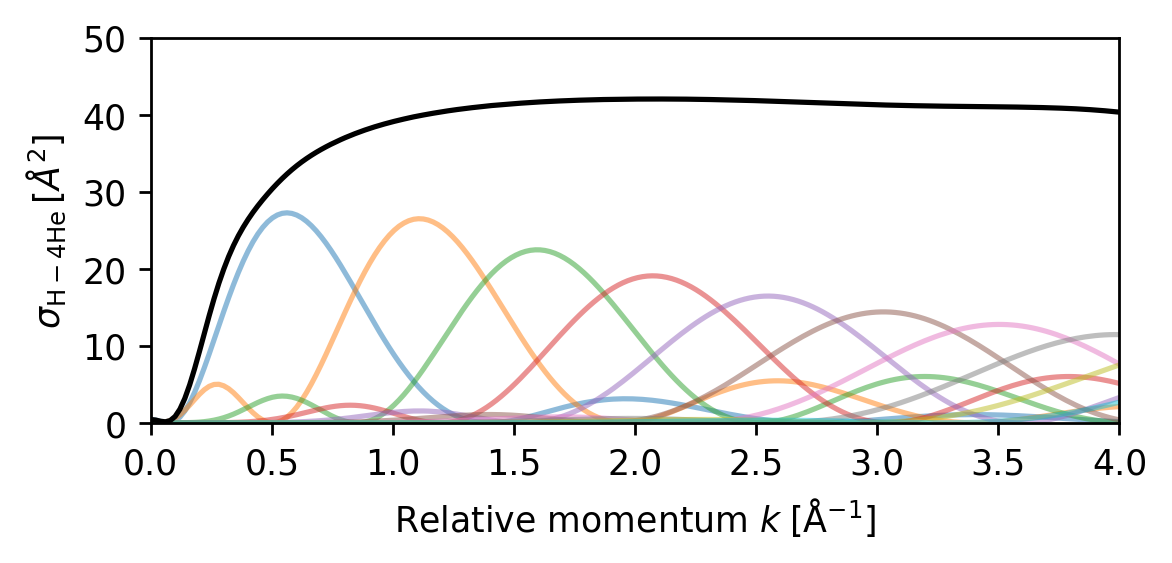

In [14]:
plt.figure(figsize=(5,2), dpi=250)
for l in sigma_T_by_l.keys():
    plt.plot(k_A, np.array(sigma_T_by_l[l])* constants.hcInEVAngstrom**2,alpha=0.5,label=r'$\mathtt{l}$='+str(l))
plt.plot(k_A, np.array(sigma_T_total) * constants.hcInEVAngstrom**2, label="Total",color='black')
#plt.plot(k[0:-5],XS_smooth[0:-5]*constants.BohrInAng**-2, ':',label="Al-Maaitah",color='dimgrey',linewidth=4)
plt.xlabel(r'Relative momentum $k\;[\mathrm{\AA}^{-1}]$')
plt.ylabel(r'$\sigma_{\mathrm{H}-4\mathrm{He}}\, [\AA^2]$')
plt.xlim(0, 4)
plt.ylim(0, 50)
#plt.title("H-4He scattering")
#plt.legend(ncol=4)
# plt.savefig("./Plots/H4HeElastic.png",dpi=250,bbox_inches='tight')

In [15]:
# Make partial waves plot for T-4He
# ModifiedMF 
muC=3.4140852245876068

#Calculate higher partial wave elastic cross sections
k_eV  = np.linspace(1e-4, 4*constants.hcInEVAngstrom, 200)
k_A = k_eV / constants.hcInEVAngstrom

r0       = 1e-9
intlimit = 100 * constants.BohrInAng/constants.hcInEVAngstrom
rhos = np.linspace(r0, intlimit, 100)



ls = np.arange(0, 10, 1)

sigma_T_by_l = {}
sigma_T_total = np.zeros_like(k_A)   # activate if you want Σ_l

for l in ls:
    sigma_T_partial = np.array([
        elastic.GetCrossSection(rhos, k, l+1e-4, muC*muH,
                                ModifiedMF, 'Radau')/2
        for k in k_eV
    ])
    sigma_T_by_l[l] = sigma_T_partial
    sigma_T_total   += sigma_T_by_l[l]

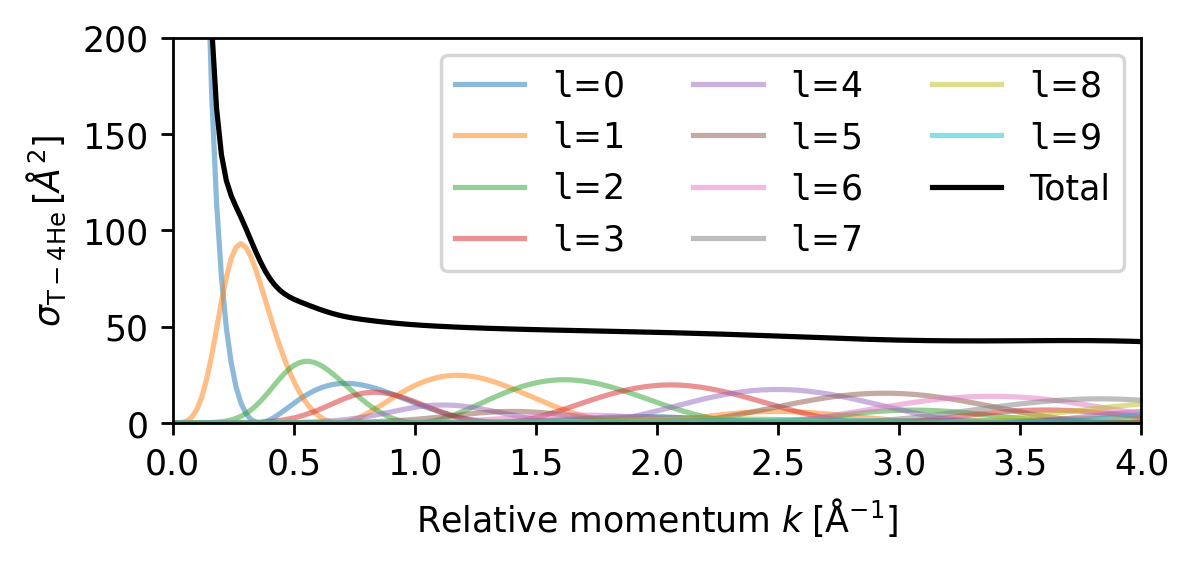

In [16]:


plt.figure(figsize=(5,2), dpi=250)
for l in sigma_T_by_l.keys():
    plt.plot(k_A, np.array(sigma_T_by_l[l])* constants.hcInEVAngstrom**2,alpha=0.5,label=r'$\mathtt{l}$='+str(l))
plt.plot(k_A, np.array(sigma_T_total) * constants.hcInEVAngstrom**2, label="Total",color='black')
#plt.plot(k[0:-5],XS_smooth[0:-5]*constants.BohrInAng**-2, ':',label="Al-Maaitah",color='dimgrey',linewidth=4)
plt.xlabel(r'Relative momentum $k\;[\mathrm{\AA}^{-1}]$')
plt.ylabel(r'$\sigma_{\mathrm{T}-4\mathrm{He}}\, [\AA^2]$')
plt.xlim(0, 4)
plt.ylim(0, 200)

plt.legend(ncol=3)
plt.savefig("./Plots/T4HeElastic.png",dpi=250,bbox_inches='tight')

In [17]:
# Get total xs vs energy
# ModifiedMF
TotalXBySpecies={}
MuBySpecies={}
for Hi in range(0,len(HMasses)):
    for Hei in range(0,len(HeMasses)):
        muC=2.*HMasses[Hi]*HeMasses[Hei]/(HMasses[Hi]+HeMasses[Hei])
        name= HAtoms[Hi]+"-"+HeAtoms[Hei]
        k_eV  = np.linspace(1e-4, 4*constants.hcInEVAngstrom, 200)
        k_A = k_eV / constants.hcInEVAngstrom

        r0       = 1e-9
        intlimit = 100 * constants.BohrInAng/constants.hcInEVAngstrom
        rhos = np.linspace(r0, intlimit, 100)



        ls = np.arange(0, 10, 1)

        sigma_T_by_l = {}
        sigma_T_total = np.zeros_like(k_A)   # activate if you want Σ_l

        for l in ls:
            sigma_T_partial = np.array([
                elastic.GetCrossSection(rhos, k, l+1e-4, muC*muH,
                                        ModifiedMF, 'Radau')/2
                for k in k_eV
            ])
            sigma_T_by_l[l] = sigma_T_partial
            sigma_T_total   += sigma_T_by_l[l]
        TotalXBySpecies[name]=sigma_T_total
        MuBySpecies[name]=muC

In [18]:
# Get total xs vs energy
# HFD-B
TotalXBySpecies_HFD_B={}
MuBySpecies_HFD_B={}
for Hi in range(0,len(HMasses)):
    for Hei in range(0,len(HeMasses)):
        muC=2.*HMasses[Hi]*HeMasses[Hei]/(HMasses[Hi]+HeMasses[Hei])
        name= HAtoms[Hi]+"-"+HeAtoms[Hei]
        k_eV  = np.linspace(1e-4, 4*constants.hcInEVAngstrom, 200)
        k_A = k_eV / constants.hcInEVAngstrom

        r0       = 1e-9
        intlimit = 100 * constants.BohrInAng/constants.hcInEVAngstrom
        rhos = np.linspace(r0, intlimit, 100)



        ls = np.arange(0, 10, 1)

        sigma_T_by_l = {}
        sigma_T_total = np.zeros_like(k_A)   # activate if you want Σ_l

        for l in ls:
            sigma_T_partial = np.array([
                elastic.GetCrossSection(rhos, k, l+1e-4, muC*muH,
                                        HFD_B, 'Radau')/2
                for k in k_eV
            ])
            sigma_T_by_l[l] = sigma_T_partial
            sigma_T_total   += sigma_T_by_l[l]
        TotalXBySpecies_HFD_B[name]=sigma_T_total
        MuBySpecies_HFD_B[name]=muC

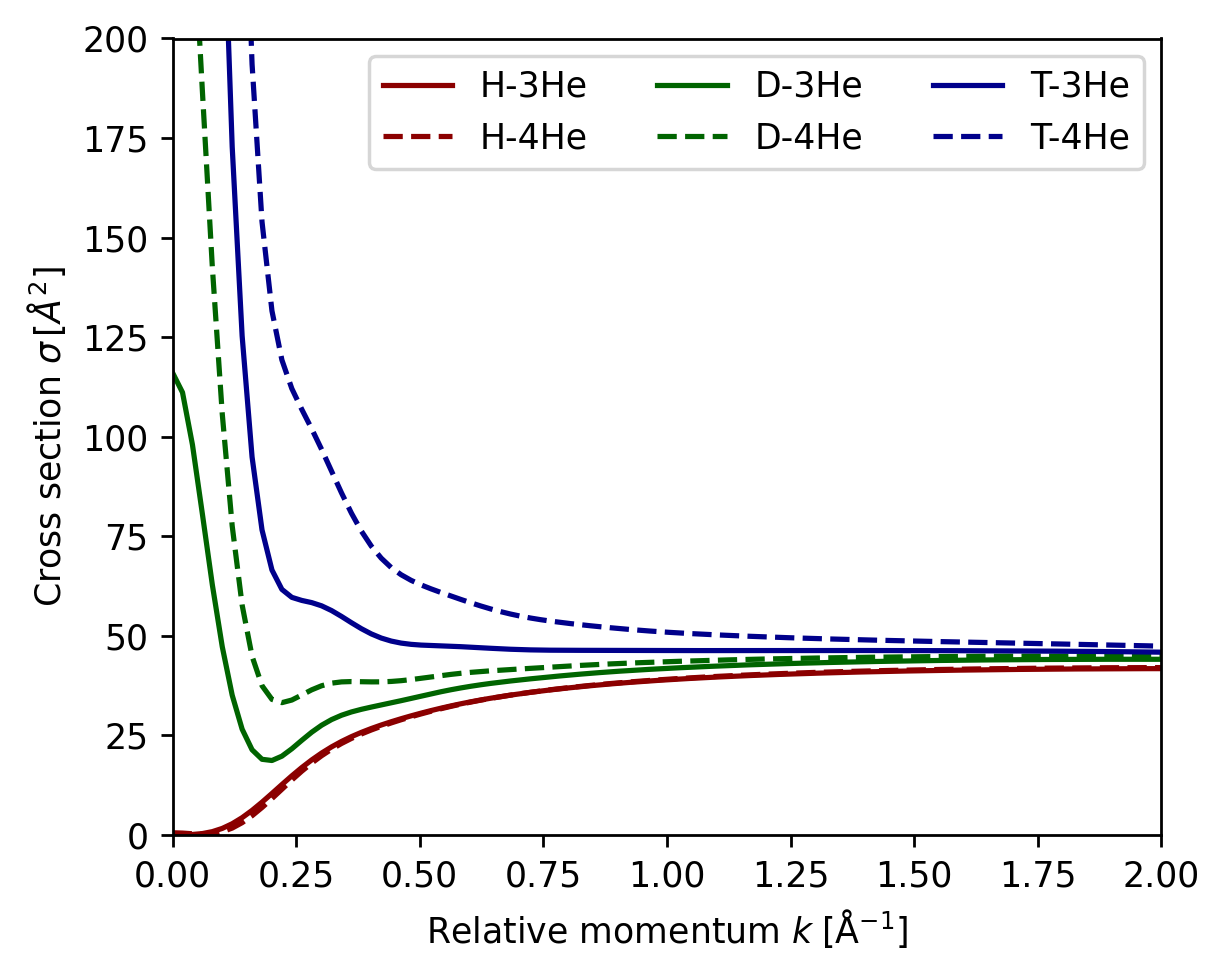

In [19]:
# Momentum plot
# HFD-B
LineStyles=['-','--','-','--','-','--']
Colors=['DarkRed','DarkRed','DarkGreen','DarkGreen','DarkBlue','DarkBlue']
plt.figure(figsize=(5,4), dpi=250)
i=0
for n in TotalXBySpecies_HFD_B.keys():
    plt.plot(k_A, np.array(TotalXBySpecies_HFD_B[n]) * constants.hcInEVAngstrom**2, label=n,color=Colors[i],linestyle=LineStyles[i])
    i=i+1

plt.xlabel(r'Relative momentum $k\;[\mathrm{\AA}^{-1}]$')
plt.ylabel(r'Cross section $\sigma\,[\AA^2]$')
plt.xlim(0, 2)
plt.ylim(0, 200)

plt.legend(ncol=3)
plt.tight_layout()
# plt.savefig("./Plots/AllCrossSections.png",dpi=250,bbox_inches='tight')


In [20]:
k_A,TotalXBySpecies_HFD_B

(array([5.06773072e-08, 2.01005529e-02, 4.02010552e-02, 6.03015575e-02,
        8.04020597e-02, 1.00502562e-01, 1.20603064e-01, 1.40703566e-01,
        1.60804069e-01, 1.80904571e-01, 2.01005073e-01, 2.21105576e-01,
        2.41206078e-01, 2.61306580e-01, 2.81407082e-01, 3.01507585e-01,
        3.21608087e-01, 3.41708589e-01, 3.61809091e-01, 3.81909594e-01,
        4.02010096e-01, 4.22110598e-01, 4.42211100e-01, 4.62311603e-01,
        4.82412105e-01, 5.02512607e-01, 5.22613109e-01, 5.42713612e-01,
        5.62814114e-01, 5.82914616e-01, 6.03015118e-01, 6.23115621e-01,
        6.43216123e-01, 6.63316625e-01, 6.83417127e-01, 7.03517630e-01,
        7.23618132e-01, 7.43718634e-01, 7.63819136e-01, 7.83919639e-01,
        8.04020141e-01, 8.24120643e-01, 8.44221146e-01, 8.64321648e-01,
        8.84422150e-01, 9.04522652e-01, 9.24623155e-01, 9.44723657e-01,
        9.64824159e-01, 9.84924661e-01, 1.00502516e+00, 1.02512567e+00,
        1.04522617e+00, 1.06532667e+00, 1.08542717e+00, 1.105527

In [21]:
data = pd.DataFrame(k_A, columns=['k_A'])
for n in TotalXBySpecies_HFD_B.keys():
    data[n] = np.array(TotalXBySpecies_HFD_B[n]) * constants.hcInEVAngstrom**2

# data.to_csv('Tables/HFD_scattering.csv')

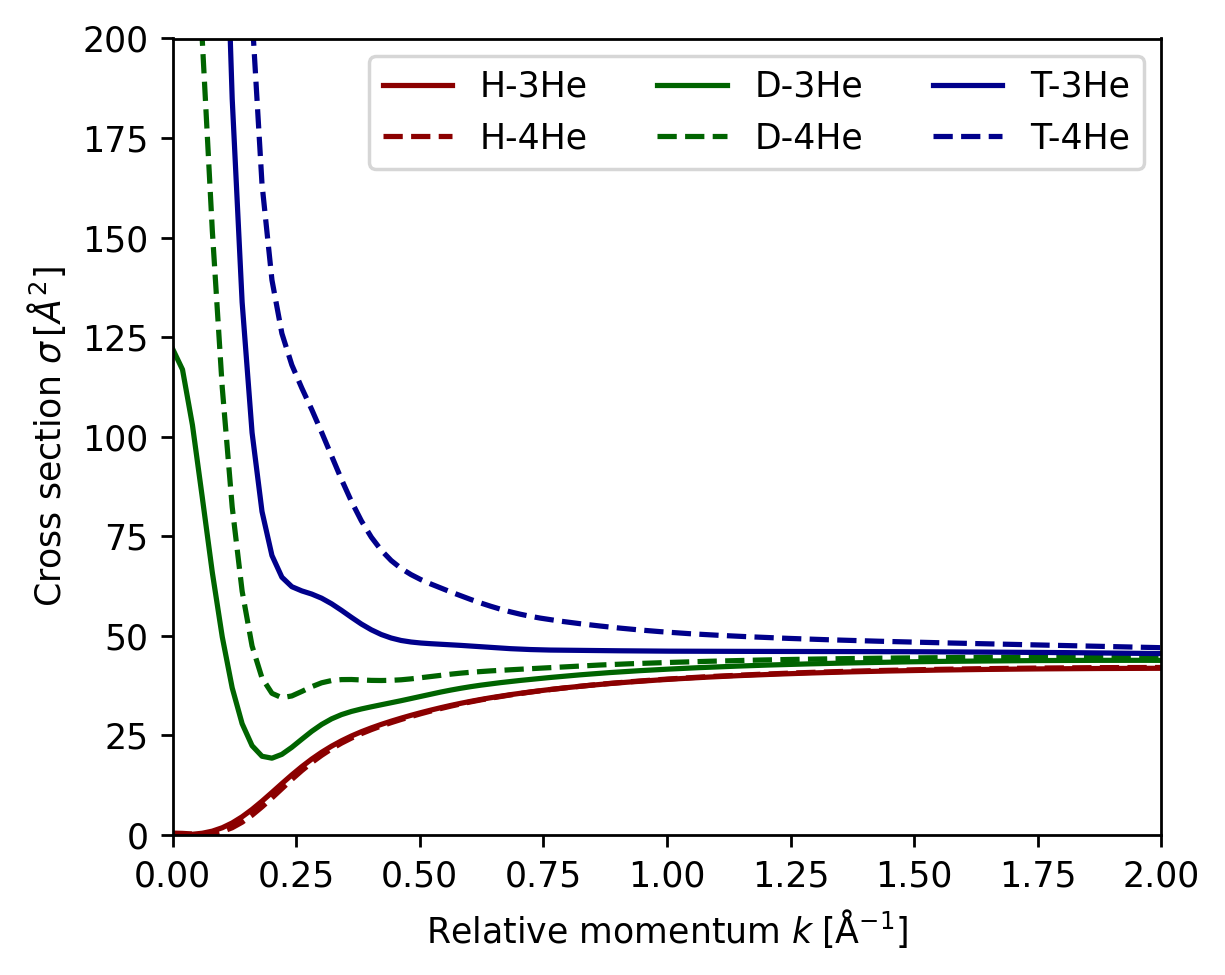

In [22]:
# Momentum plot

LineStyles=['-','--','-','--','-','--']
Colors=['DarkRed','DarkRed','DarkGreen','DarkGreen','DarkBlue','DarkBlue']
plt.figure(figsize=(5,4), dpi=250)
i=0
for n in TotalXBySpecies.keys():
    plt.plot(k_A, np.array(TotalXBySpecies[n]) * constants.hcInEVAngstrom**2, label=n,color=Colors[i],linestyle=LineStyles[i])
    i=i+1

plt.xlabel(r'Relative momentum $k\;[\mathrm{\AA}^{-1}]$')
plt.ylabel(r'Cross section $\sigma\,[\AA^2]$')
plt.xlim(0, 2)
plt.ylim(0, 200)
plt.legend(ncol=3)
plt.tight_layout()
# plt.savefig("./Plots/AllCrossSections.png",dpi=250,bbox_inches='tight')


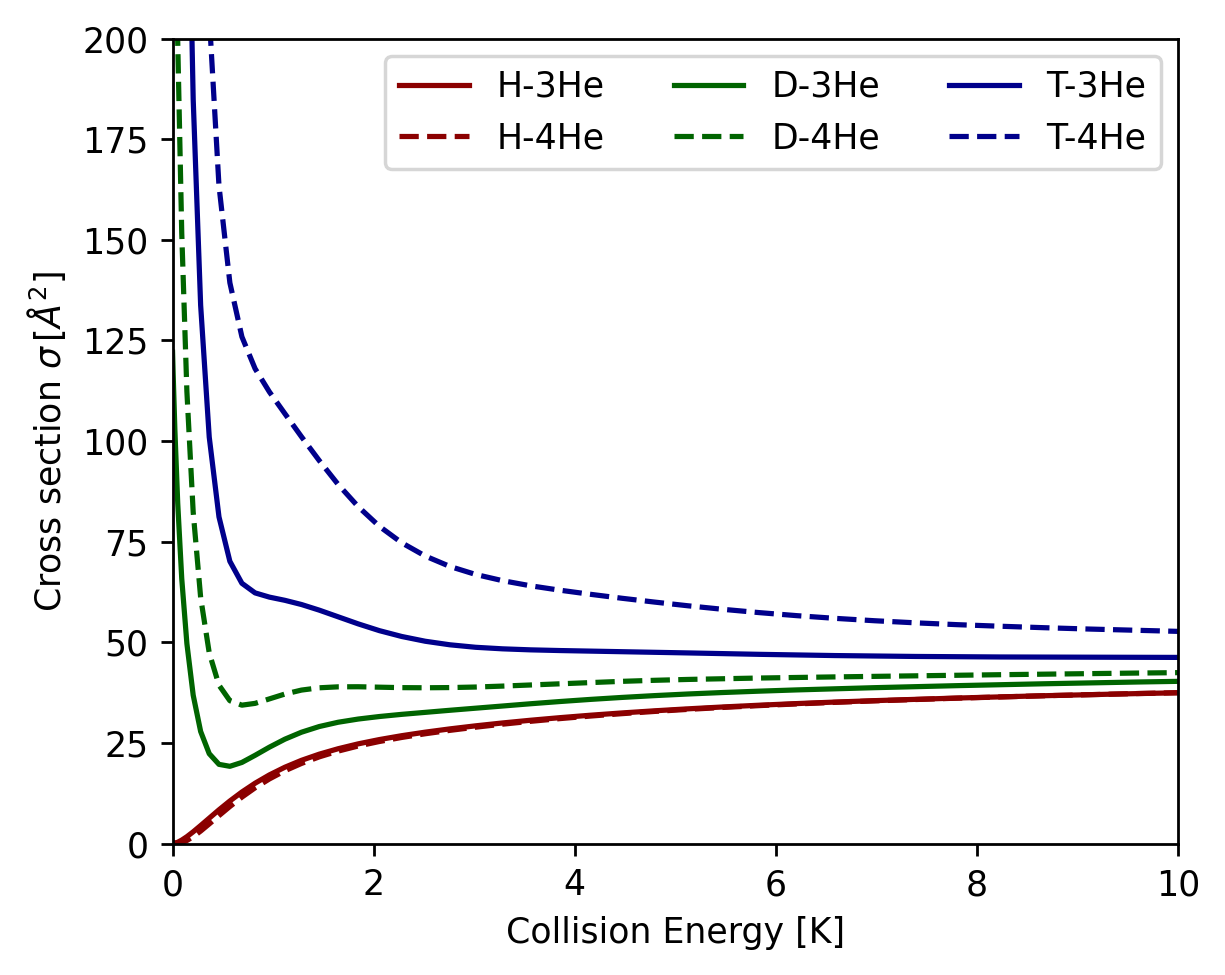

In [23]:
# Linear energy plot

LineStyles=['-','--','-','--','-','--']
Colors=['DarkRed','DarkRed','DarkGreen','DarkGreen','DarkBlue','DarkBlue']
plt.figure(figsize=(5,4), dpi=250)
kB=8.617e-5
i=0
for n in TotalXBySpecies.keys():
    E=k_eV**2/(2*muC*muH)

    plt.plot(E/kB, np.array(TotalXBySpecies[n]) * constants.hcInEVAngstrom**2, label=n,color=Colors[i],linestyle=LineStyles[i])
    i=i+1

plt.xlabel(r'Collision Energy [K]')
plt.ylabel(r'Cross section $\sigma\,[\AA^2]$')
plt.xlim(0, 10)
plt.ylim(0, 200)
plt.legend(ncol=3)
plt.tight_layout()
plt.savefig("./Plots/AllCrossSectionsE.png",dpi=250,bbox_inches='tight')

In [24]:
# Calc on log energy scale

TotalXBySpecies={}
MuBySpecies={}
for Hi in range(0,len(HMasses)):
    for Hei in range(0,len(HeMasses)):
        muC=2.*HMasses[Hi]*HeMasses[Hei]/(HMasses[Hi]+HeMasses[Hei])
        name= HAtoms[Hi]+"-"+HeAtoms[Hei]

        k_eV  = np.logspace(0, np.log10(4*constants.hcInEVAngstrom), 100)
        k_A = k_eV / constants.hcInEVAngstrom

        r0       = 1e-9
        intlimit = 100 * constants.BohrInAng/constants.hcInEVAngstrom
        rhos = np.linspace(r0, intlimit, 100)



        ls = np.arange(0, 10, 1)

        sigma_T_by_l = {}
        sigma_T_total = np.zeros_like(k_A)   # activate if you want Σ_l

        for l in ls:
            sigma_T_partial = np.array([
                elastic.GetCrossSection(rhos, k, l+1e-4, muC*muH,
                                        ModifiedMF, 'Radau')/2
                for k in k_eV
            ])
            sigma_T_by_l[l] = sigma_T_partial
            sigma_T_total   += sigma_T_by_l[l]
        TotalXBySpecies[name]=sigma_T_total
        MuBySpecies[name]=muC

In [25]:
# Calc on log energy scale
# HFD-B
TotalXBySpecies={}
MuBySpecies={}
for Hi in range(0,len(HMasses)):
    for Hei in range(0,len(HeMasses)):
        muC=2.*HMasses[Hi]*HeMasses[Hei]/(HMasses[Hi]+HeMasses[Hei])
        name= HAtoms[Hi]+"-"+HeAtoms[Hei]

        k_eV  = np.logspace(0, np.log10(4*constants.hcInEVAngstrom), 100)
        k_A = k_eV / constants.hcInEVAngstrom

        r0       = 1e-9
        intlimit = 100 * constants.BohrInAng/constants.hcInEVAngstrom
        rhos = np.linspace(r0, intlimit, 100)



        ls = np.arange(0, 10, 1)

        sigma_T_by_l = {}
        sigma_T_total = np.zeros_like(k_A)   # activate if you want Σ_l

        for l in ls:
            sigma_T_partial = np.array([
                elastic.GetCrossSection(rhos, k, l+1e-4, muC*muH,
                                        HFD_B, 'Radau')/2
                for k in k_eV
            ])
            sigma_T_by_l[l] = sigma_T_partial
            sigma_T_total   += sigma_T_by_l[l]
        TotalXBySpecies[name]=sigma_T_total
        MuBySpecies[name]=muC

/var/folders/x8/m88g9m690wb3gf4t7ds85nzw0000gn/T/ipykernel_26393/354150214.py:16: UserWarning: Attempt to set non-positive ylim on a log-scaled axis will be ignored.
  plt.ylim(0, 4000)


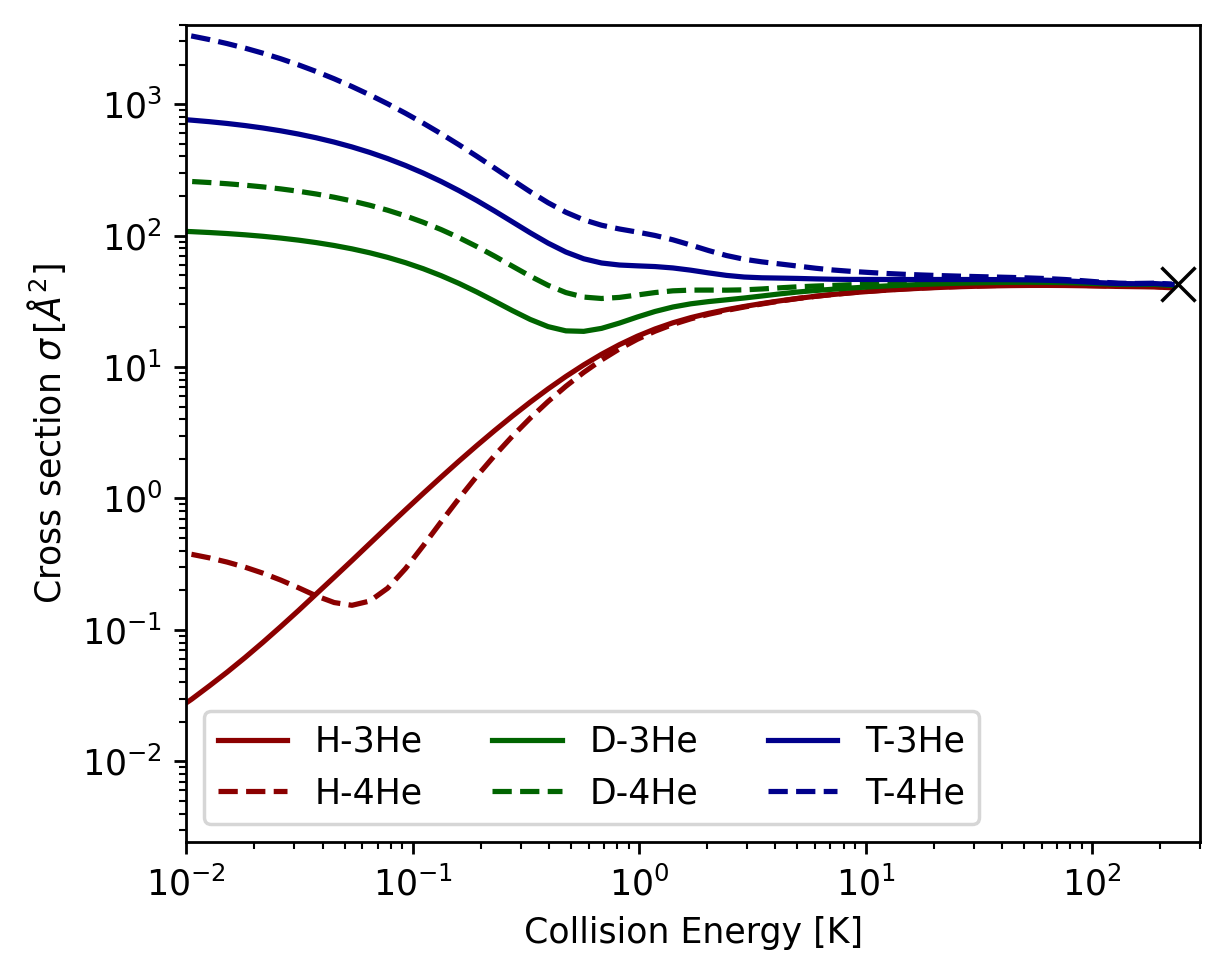

In [26]:
# Log energy plot
LineStyles=['-','--','-','--','-','--']
Colors=['DarkRed','DarkRed','DarkGreen','DarkGreen','DarkBlue','DarkBlue']
plt.figure(figsize=(5,4), dpi=250)
kB=8.617e-5
i=0
for n in TotalXBySpecies.keys():
    E=k_eV**2/(2*muC*muH)

    plt.plot(E/kB, np.array(TotalXBySpecies[n]) * constants.hcInEVAngstrom**2, label=n,color=Colors[i],linestyle=LineStyles[i])
    i=i+1

plt.xlabel(r'Collision Energy [K]')
plt.ylabel(r'Cross section $\sigma\,[\AA^2]$')
plt.loglog()
plt.ylim(0, 4000)
plt.legend(ncol=3)
plt.xlim(1e-2,300)
VDWXS=2*np.pi*(1.2+1.4)**2
plt.plot([240],[VDWXS],'x',color='black',markerfacecolor='white',markersize=10)
plt.tight_layout()
# plt.savefig("./Plots/AllCrossSectionsT.png",dpi=250,bbox_inches='tight')


In [27]:
data_energy = pd.DataFrame(E/kB, columns=['E'])
for n in TotalXBySpecies.keys():
    data_energy[n] = np.array(TotalXBySpecies[n]) * constants.hcInEVAngstrom**2

data_energy.to_csv('Tables/HFD_scattering_log.csv')

In [28]:
E=k_eV**2/(2*muC*muH)

AllEs=[]
HIso=[]
HeIso=[]
SigmaHFD_B=[]

for spec in TotalXBySpecies.keys():
    for i in range(0,len(TotalXBySpecies[spec])):
        HIso.append(spec.split("-")[0])
        HeIso.append(spec.split("-")[1])
        AllEs.append(E[i]/kB)
        SigmaHFD_B.append(TotalXBySpecies[spec][i])
        # SigmaMF.append(TotalXBySpeciesMF[spec][i])
df = pd.DataFrame({
                    'E':AllEs,
                    'HIso':HIso,
                    'HeIso':HeIso,
                    'sigmaHFD_B':SigmaHFD_B,
                   })
df.to_csv('Tables/HeH_CrossSections_new.csv')

In [29]:
#Calculate it for the other potential

TotalXBySpeciesMF={}
MuBySpecies={}
for Hi in range(0,len(HMasses)):
    for Hei in range(0,len(HeMasses)):
        muC=2.*HMasses[Hi]*HeMasses[Hei]/(HMasses[Hi]+HeMasses[Hei])
        name= HAtoms[Hi]+"-"+HeAtoms[Hei]

        k_eV  = np.logspace(0, np.log10(4*constants.hcInEVAngstrom), 100)
        k_A = k_eV / constants.hcInEVAngstrom

        r0       = 1e-9
        intlimit = 100 * constants.BohrInAng/constants.hcInEVAngstrom
        rhos = np.linspace(r0, intlimit, 100)



        ls = np.arange(0, 10, 1)

        sigma_T_by_l = {}
        sigma_T_total = np.zeros_like(k_A)   # activate if you want Σ_l

        for l in ls:
            sigma_T_partial = np.array([
                elastic.GetCrossSection(rhos, k, l+1e-4, muC*muH,
                                        ExtendedMF, 'Radau')/2
                for k in k_eV
            ])
            sigma_T_by_l[l] = sigma_T_partial
            sigma_T_total   += sigma_T_by_l[l]
        TotalXBySpeciesMF[name]=sigma_T_total
        MuBySpecies[name]=muC

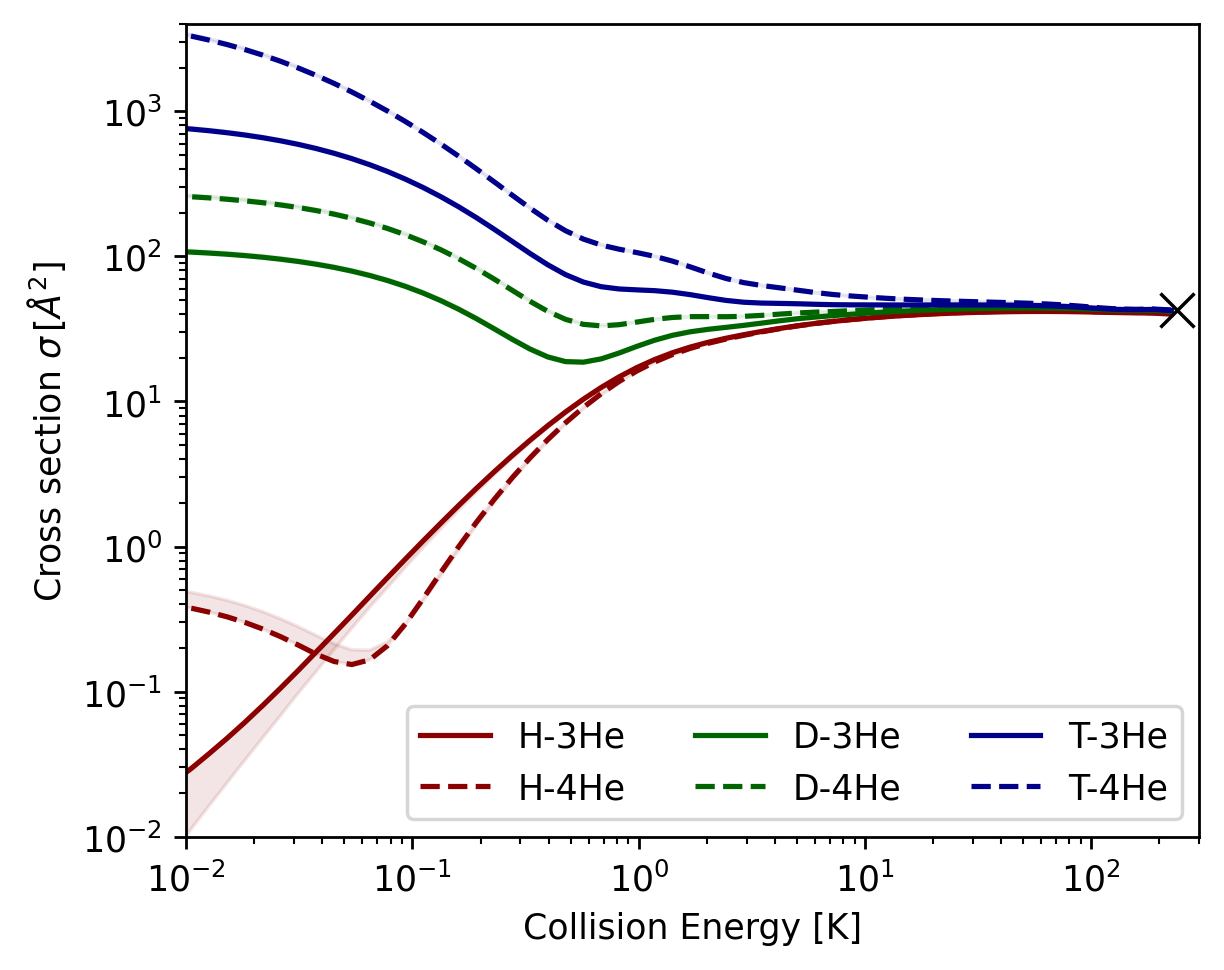

In [30]:
#Make plot with error band
LineStyles=['-','--','-','--','-','--']
Colors=['DarkRed','DarkRed','DarkGreen','DarkGreen','DarkBlue','DarkBlue']
plt.figure(figsize=(5,4), dpi=250)
i=0
for n in TotalXBySpecies.keys():
    E=k_eV**2/(2*muC*muH)

    plt.plot(E/kB, np.array(TotalXBySpecies[n]) * constants.hcInEVAngstrom**2, label=n,color=Colors[i],linestyle=LineStyles[i])
    plt.fill_between(E/kB, np.array(TotalXBySpeciesMF[n]) * constants.hcInEVAngstrom**2,np.array(TotalXBySpecies[n]) * constants.hcInEVAngstrom**2, color=Colors[i],linestyle='-',alpha=0.1)

    i=i+1

plt.xlabel(r'Collision Energy [K]')
plt.ylabel(r'Cross section $\sigma\,[\AA^2]$')
plt.loglog()
plt.legend(ncol=3)
plt.xlim(1e-2,300)
VDWXS=2*np.pi*(1.2+1.4)**2
plt.plot([240],[VDWXS],'x',color='black',markerfacecolor='white',markersize=10)
plt.tight_layout()
plt.ylim(1e-2,4e3)
plt.savefig("./Plots/AllCrossSectionsE.png",dpi=250,bbox_inches='tight')


In [41]:
data = pd.read_csv('Tables/HeH_CrossSections_2.csv')

In [37]:
data[100:201:]

,Unnamed: 0,E,HIso,HeIso,sigmaMF,sigmaModMF,sigmaR2,sigmaHFD_B
100,100,0.000004,H,4He,1.102823e-07,1.638858e-07,3.216144e-08,1.311922e-07
101,101,0.000004,H,4He,1.102798e-07,1.638827e-07,3.216015e-08,1.311895e-07
102,102,0.000005,H,4He,1.102768e-07,1.638789e-07,3.215861e-08,1.311862e-07
103,103,0.000006,H,4He,1.102732e-07,1.638745e-07,3.215676e-08,1.311823e-07
104,104,0.000007,H,4He,1.102689e-07,1.638691e-07,3.215454e-08,1.311776e-07
...,...,...,...,...,...,...,...,...
196,196,131.019796,H,4He,1.059576e-05,1.051511e-05,1.091271e-05,1.059258e-05
197,197,157.061294,H,4He,1.055335e-05,1.047265e-05,1.087286e-05,1.055193e-05
198,198,188.278800,H,4He,1.051954e-05,1.043757e-05,1.082080e-05,1.051658e-05
199,199,225.701099,H,4He,1.036086e-05,1.027956e-05,1.059149e-05,1.034935e-05


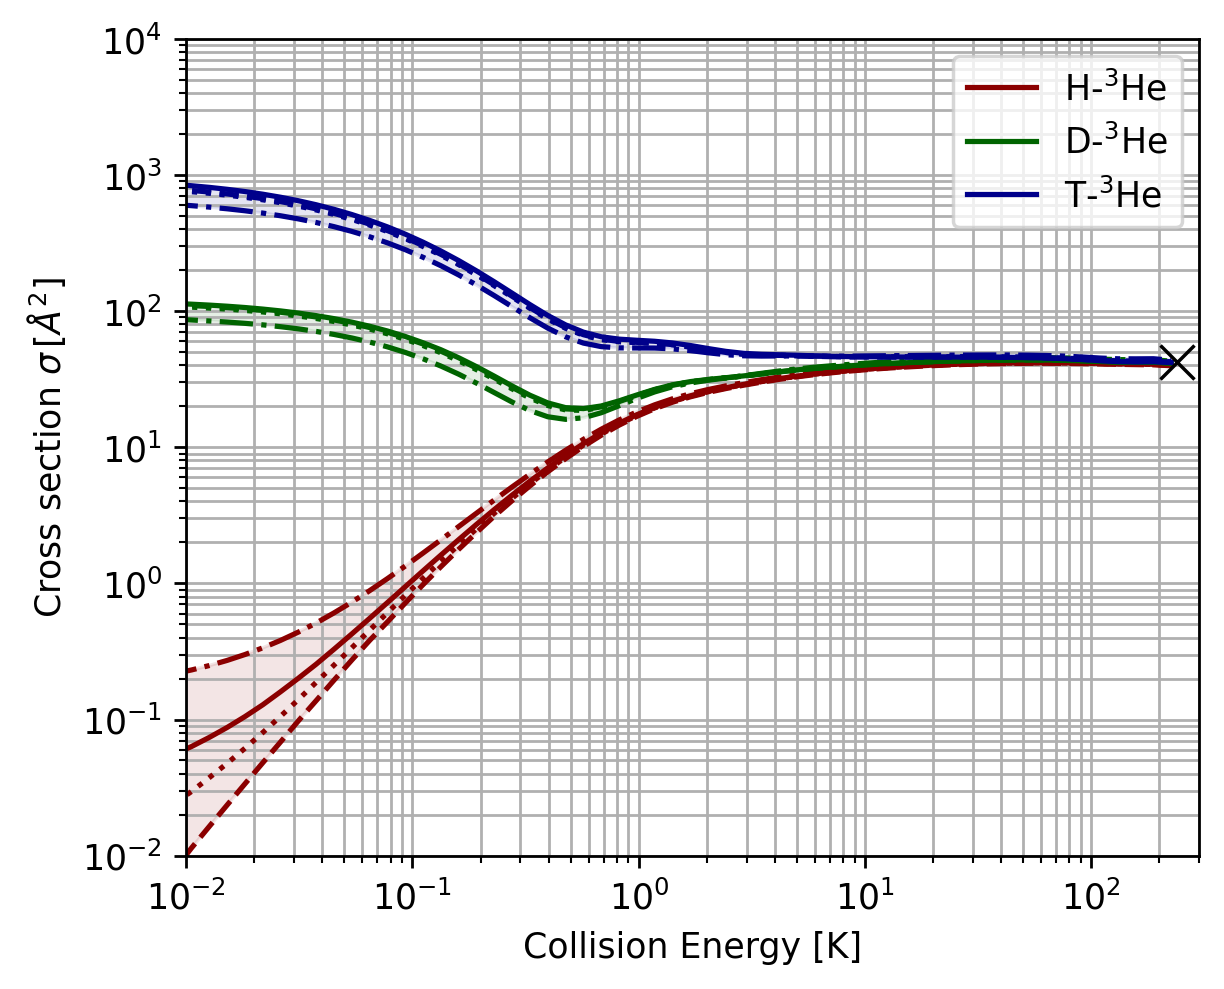

In [45]:
Colors=['DarkRed','DarkRed','DarkGreen','DarkGreen','DarkBlue','DarkBlue']

plt.figure(figsize=(5,4), dpi=250)
plt.plot(data[:100:]['E'], data[:100:]['sigmaMF'], label = r'H-$^3$He', color = Colors[0])
plt.plot(data[:100:]['E'], data[:100:]['sigmaHFD_B'],  color = Colors[0], ls = ':')
plt.plot(data[:100:]['E'], data[:100:]['sigmaModMF'],  color = Colors[0], ls='--')
plt.plot(data[:100:]['E'], data[:100:]['sigmaR2'],  color = Colors[0], ls = '-.')
plt.fill_between(data[:100:]['E'], 
                 data[:100:]['sigmaModMF'],
                 data[:100:]['sigmaR2'], color=Colors[0],linestyle='-',alpha=0.1)


plt.plot(data[201:300:]['E'], data[201:300:]['sigmaMF'], label = r'D-$^3$He', color = Colors[2])
plt.plot(data[201:300:]['E'], data[201:300:]['sigmaModMF'],  color = Colors[2], ls='--')
plt.plot(data[201:300:]['E'], data[201:300:]['sigmaR2'],  color =  Colors[2], ls = '-.')
plt.plot(data[201:300:]['E'], data[201:300:]['sigmaHFD_B'],  color =  Colors[2], ls = ':')
plt.fill_between(data[201:300:]['E'], 
                 data[201:300:]['sigmaR2'],
                 data[201:300:]['sigmaMF'], color=Colors[2],linestyle='-',alpha=0.1)


plt.plot(data[401:500:]['E'], data[401:500:]['sigmaMF'], label = r'T-$^3$He', color = Colors[4])
plt.plot(data[401:500:]['E'], data[401:500:]['sigmaModMF'],  color = Colors[4], ls ='--')
plt.plot(data[401:500:]['E'], data[401:500:]['sigmaR2'], color = Colors[4], ls = '-.')
plt.plot(data[401:500:]['E'], data[401:500:]['sigmaHFD_B'],  color = Colors[4], ls = ':')
plt.fill_between(data[401:500:]['E'], 
                 data[401:500:]['sigmaMF'],
                 data[401:500:]['sigmaR2'], color=Colors[4],linestyle='-',alpha=0.1)





plt.xlabel(r'Collision Energy [K]')
plt.ylabel(r'Cross section $\sigma\,[\AA^2]$')
plt.loglog()
plt.legend()

plt.xlim(1e-2,300)
VDWXS=2*np.pi*(1.2+1.4)**2
plt.plot([240],[VDWXS],'x',color='black',markerfacecolor='white',markersize=10)
plt.tight_layout()
plt.grid(which='both')

plt.ylim(1e-2,1e4)
plt.savefig('Plots/3He_spicies.png')

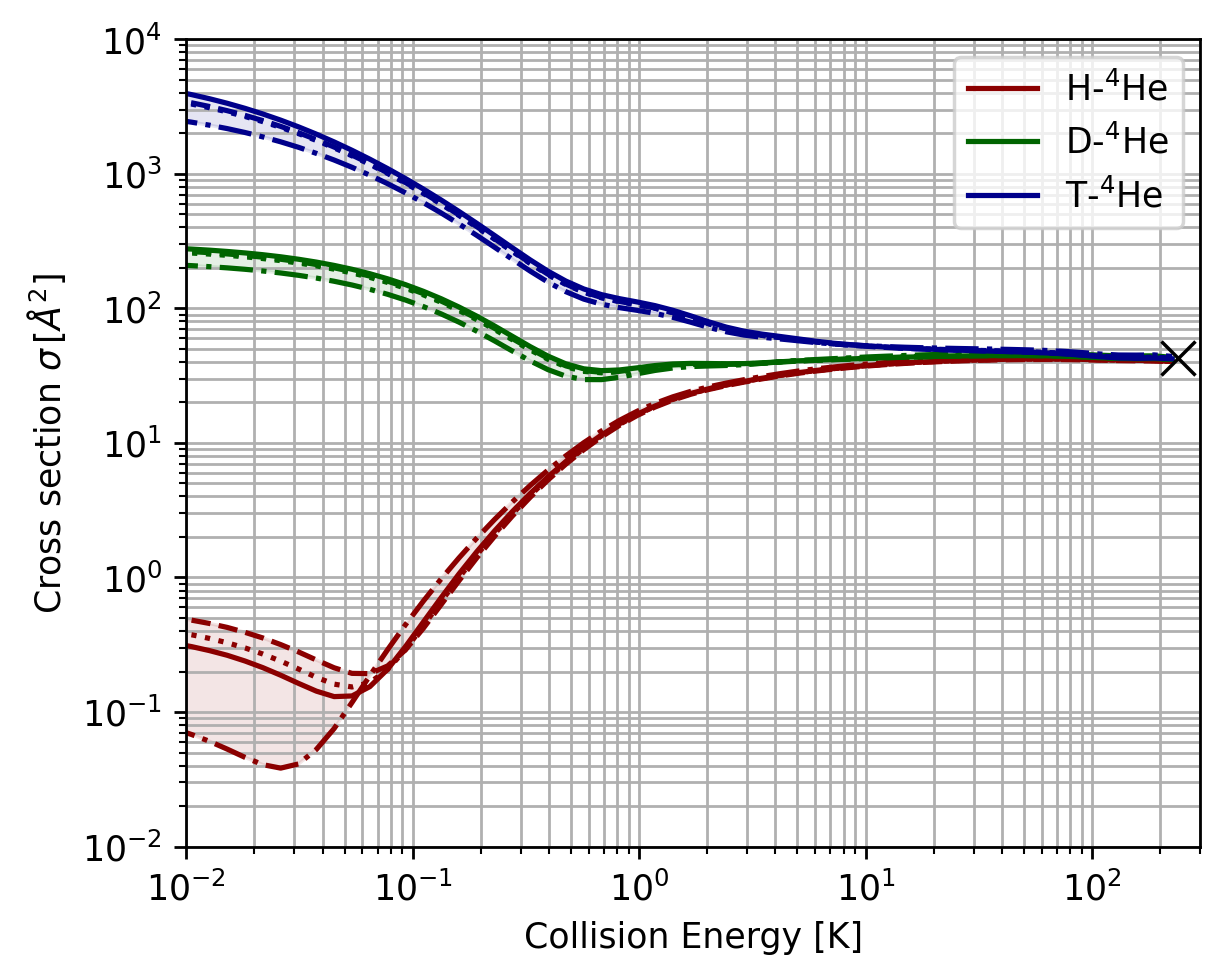

In [47]:
Colors=['DarkRed','DarkRed','DarkGreen','DarkGreen','DarkBlue','DarkBlue']

plt.figure(figsize=(5,4), dpi=250)
plt.plot(data[101:200:]['E'], data[101:200:]['sigmaMF'], label = r'H-$^4$He', color = Colors[0])
plt.plot(data[101:200:]['E'], data[101:200:]['sigmaModMF'] ,  color = Colors[0], ls = '--')
plt.plot(data[101:200:]['E'], data[101:200:]['sigmaR2'] ,  color = Colors[0], ls = '-.')
plt.plot(data[101:200:]['E'], data[101:200:]['sigmaHFD_B'] ,  color = Colors[0], ls = ':')
plt.fill_between(data[101:200:]['E'], 
                 data[101:200:]['sigmaModMF'],
                 data[101:200:]['sigmaR2'], color=Colors[0],linestyle='-',alpha=0.1)



plt.plot(data[301:400:]['E'], data[301:400:]['sigmaMF'], label = r'D-$^4$He', color = Colors[2])
plt.plot(data[301:400:]['E'], data[301:400:]['sigmaModMF'],  color = Colors[2], ls = '--')
plt.plot(data[301:400:]['E'], data[301:400:]['sigmaR2'],  color = Colors[2], ls = '-.')
plt.plot(data[301:400:]['E'], data[301:400:]['sigmaHFD_B'],  color = Colors[2], ls = ':')
plt.fill_between(data[301:400:]['E'], 
                 data[301:400:]['sigmaR2'],
                 data[301:400:]['sigmaMF'], color=Colors[2],linestyle='-',alpha=0.1)



plt.plot(data[501:600:]['E'], data[501:600:]['sigmaMF'], label = r'T-$^4$He', color = Colors[4])
plt.plot(data[501:600:]['E'], data[501:600:]['sigmaModMF'],  color = Colors[4], ls = '--')
plt.plot(data[501:600:]['E'], data[501:600:]['sigmaR2'],  color = Colors[4], ls = '-.')
plt.plot(data[501:600:]['E'], data[501:600:]['sigmaHFD_B'],  color = Colors[4], ls = ':')
plt.fill_between(data[501:600:]['E'], 
                 data[501:600:]['sigmaMF'],
                 data[501:600:]['sigmaR2'], color=Colors[4],linestyle='-',alpha=0.1)



plt.xlabel(r'Collision Energy [K]')
plt.ylabel(r'Cross section $\sigma\,[\AA^2]$')
plt.loglog()
plt.legend()

plt.xlim(1e-2,300)
VDWXS=2*np.pi*(1.2+1.4)**2
plt.plot([240],[VDWXS],'x',color='black',markerfacecolor='white',markersize=10)
plt.tight_layout()
plt.grid(which='both')
plt.ylim(1e-2,1e4)
plt.savefig('Plots/4He_spicies.png')

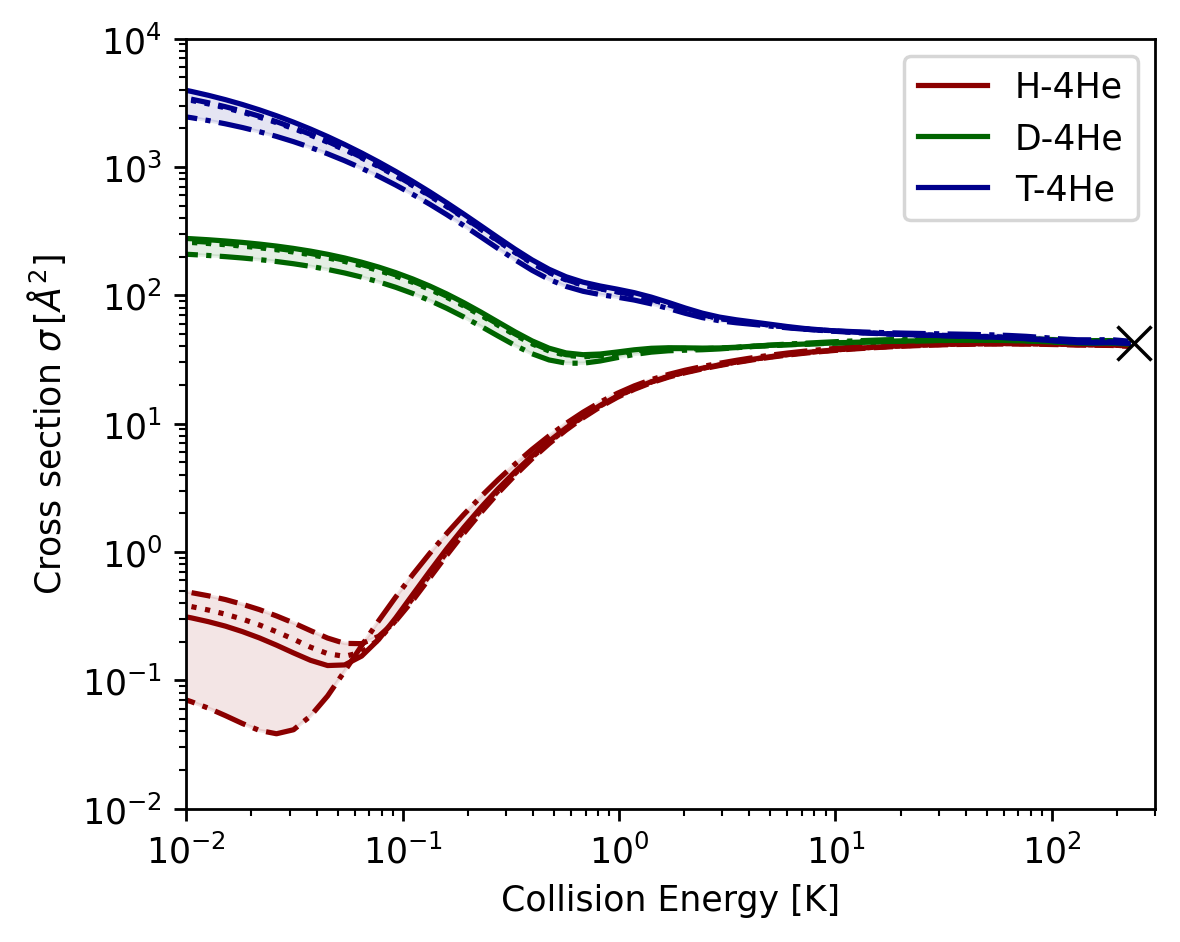

In [35]:
Colors=['DarkRed','DarkRed','DarkGreen','DarkGreen','DarkBlue','DarkBlue']

plt.figure(figsize=(5,4), dpi=250)
plt.plot(data[101:200:]['E'], data[101:200:]['sigmaMF'] * constants.hcInEVAngstrom**2, label = 'H-4He', color = Colors[0])
plt.plot(data[101:200:]['E'], data[101:200:]['sigmaModMF'] * constants.hcInEVAngstrom**2,  color = Colors[0], ls = '--')
plt.plot(data[101:200:]['E'], data[101:200:]['sigmaR2'] * constants.hcInEVAngstrom**2,  color = Colors[0], ls = '-.')
plt.plot(data[101:200:]['E'], data[101:200:]['sigmaHFD_B'] * constants.hcInEVAngstrom**2,  color = Colors[0], ls = ':')
plt.fill_between(data[101:200:]['E'], 
                 data[101:200:]['sigmaModMF'] * constants.hcInEVAngstrom**2,
                 data[101:200:]['sigmaR2'] * constants.hcInEVAngstrom**2, color=Colors[0],linestyle='-',alpha=0.1)



plt.plot(data[301:400:]['E'], data[301:400:]['sigmaMF'] * constants.hcInEVAngstrom**2, label = 'D-4He', color = Colors[2])
plt.plot(data[301:400:]['E'], data[301:400:]['sigmaModMF'] * constants.hcInEVAngstrom**2,  color = Colors[2], ls = '--')
plt.plot(data[301:400:]['E'], data[301:400:]['sigmaR2'] * constants.hcInEVAngstrom**2,  color = Colors[2], ls = '-.')
plt.plot(data[301:400:]['E'], data[301:400:]['sigmaHFD_B'] * constants.hcInEVAngstrom**2,  color = Colors[2], ls = ':')
plt.fill_between(data[301:400:]['E'], 
                 data[301:400:]['sigmaR2'] * constants.hcInEVAngstrom**2,
                 data[301:400:]['sigmaMF'] * constants.hcInEVAngstrom**2, color=Colors[2],linestyle='-',alpha=0.1)



plt.plot(data[501:600:]['E'], data[501:600:]['sigmaMF'] * constants.hcInEVAngstrom**2, label = 'T-4He', color = Colors[4])
plt.plot(data[501:600:]['E'], data[501:600:]['sigmaModMF'] * constants.hcInEVAngstrom**2,  color = Colors[4], ls = '--')
plt.plot(data[501:600:]['E'], data[501:600:]['sigmaR2'] * constants.hcInEVAngstrom**2,  color = Colors[4], ls = '-.')
plt.plot(data[501:600:]['E'], data[501:600:]['sigmaHFD_B'] * constants.hcInEVAngstrom**2,  color = Colors[4], ls = ':')
plt.fill_between(data[501:600:]['E'], 
                 data[501:600:]['sigmaMF'] * constants.hcInEVAngstrom**2,
                 data[501:600:]['sigmaR2'] * constants.hcInEVAngstrom**2, color=Colors[4],linestyle='-',alpha=0.1)


plt.xlabel(r'Collision Energy [K]')
plt.ylabel(r'Cross section $\sigma\,[\AA^2]$')
plt.loglog()
plt.legend()
plt.xlim(1e-2,300)
VDWXS=2*np.pi*(1.2+1.4)**2
plt.plot([240],[VDWXS],'x',color='black',markerfacecolor='white',markersize=10)
# plt.tight_layout()
plt.ylim(1e-2,1e4)
# plt.ylim(2e2,4e2)
plt.savefig('Plots/4He_spicies.png')